# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [243]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import UndirectedGraph
from matplotlib.colors import LinearSegmentedColormap


In [193]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [194]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)

In [195]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  4.57it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  2.50it/s]

Finished loading graph_power


In [196]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:03<00:38,  3.85s/it]

Finished loading WDN_1997
Finished loading WDN_1992


Loading GML WTW Files:  27%|██▋       | 3/11 [00:04<00:08,  1.09s/it]

Finished loading WDN_2000


Loading GML WTW Files:  45%|████▌     | 5/11 [00:05<00:04,  1.31it/s]

...

Finished loading WDN_2002
Finished loading WDN_1996


Loading GML WTW Files:  82%|████████▏ | 9/11 [00:06<00:00,  2.42it/s]

Finished loading WDN_1995


Loading GML WTW Files: 100%|██████████| 11/11 [00:07<00:00,  1.39it/s]

Finished loading WDN_1999
Finished loading WDN_2001


# I ERGMs

In [197]:
graphs

{'graph_eu_airlines': <networkx.classes.graph.Graph at 0x19f55ff50>,
 'graph_power': <networkx.classes.graph.Graph at 0x19f94ff90>}

In [198]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x1a0a12250>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x1a015e790>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x1a0a03dd0>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x1a081d350>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x19f715f90>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x1a0363fd0>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x1a1785b90>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x1a058a750>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x1a1779810>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x1a20de850>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x1a259f050>}

## 1. Compute the strength assortativity coefficient on the data.
Hint: Pay attention: the underlying data (WTW) are weighted and direted, meaning you should account
for four different kind of assortativity: in–in, in–out, out–in, out–out.

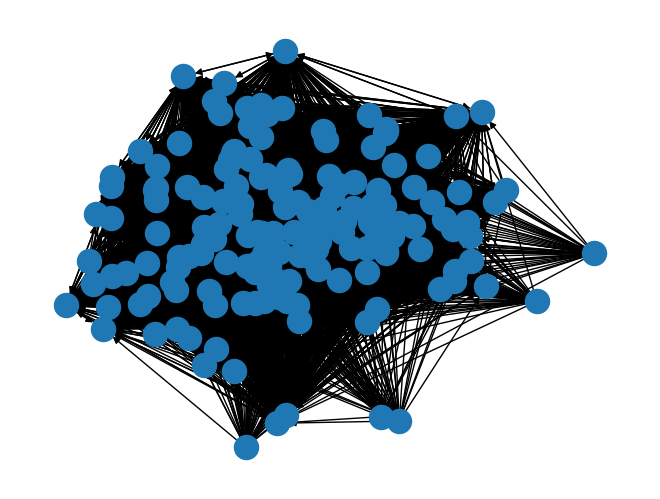

In [199]:
nx.draw(G=graphs_wtn["WDN_1997"])

In [200]:
for graph_name, graph in graphs_wtn.items():
    pass

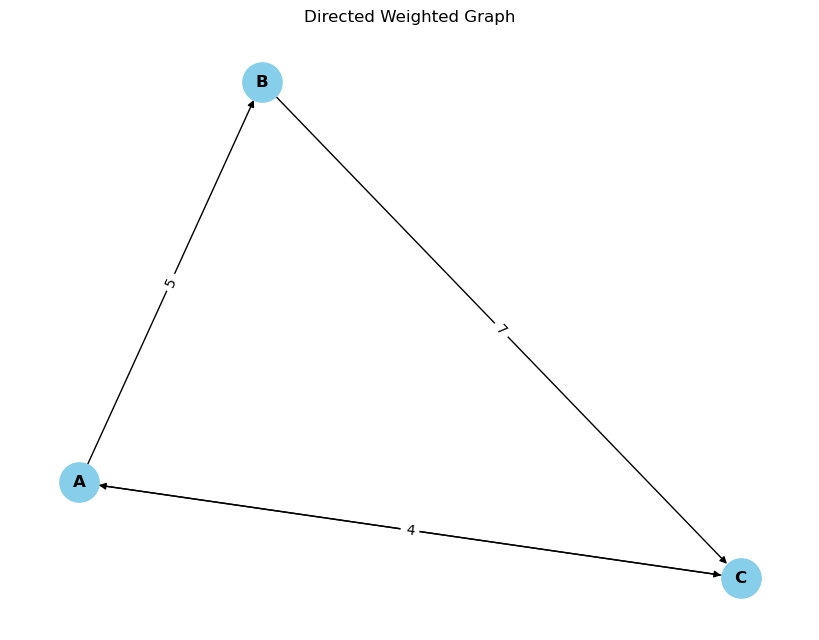

In [201]:
G = nx.DiGraph()

# Add weighted edges
G.add_edge('A', 'B', weight=5)
G.add_edge('A', 'C', weight=3)
G.add_edge('B', 'C', weight=7)
G.add_edge('C', 'A', weight=4)

# Plot the graph
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)  # Set the layout for consistent plotting

# Draw nodes and labels
nx.draw(G, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold')

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Weighted Graph')
plt.show()

In [202]:
def calculate_assortativity(graph):
    in_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='in', weight='weight')
    in_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='out', weight='weight')
    out_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='in', weight='weight')
    out_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='out', weight='weight')

    # Create a dictionary to store assortativity values
    assortativity_dict = {
        "In-In Assortativity": in_in,
        "In-Out Assortativity": in_out,
        "Out-In Assortativity": out_in,
        "Out-Out Assortativity": out_out
    }

    # Return dictionary with assortativity values
    return assortativity_dict

In [203]:
assortativities = {}
for graph_name, graph in graphs_wtn.items():
    assortativities[graph_name] = calculate_assortativity(graph=graph)
    
print(assortativities)

{'WDN_1997': {'In-In Assortativity': -0.07368635207387701, 'In-Out Assortativity': -0.07132955497657792, 'Out-In Assortativity': -0.07171683897072376, 'Out-Out Assortativity': -0.06970079872009399}, 'WDN_1992': {'In-In Assortativity': -0.04868776409103533, 'In-Out Assortativity': -0.046647404340923876, 'Out-In Assortativity': -0.059869793086991335, 'Out-Out Assortativity': -0.05760318920541264}, 'WDN_2000': {'In-In Assortativity': -0.0631970717497539, 'In-Out Assortativity': -0.06467170213846346, 'Out-In Assortativity': -0.06539073425903164, 'Out-Out Assortativity': -0.06730072607061888}, 'WDN_1998': {'In-In Assortativity': -0.0655705781839572, 'In-Out Assortativity': -0.06540616504184192, 'Out-In Assortativity': -0.06572057397949527, 'Out-Out Assortativity': -0.06583617855060356}, 'WDN_1994': {'In-In Assortativity': -0.07868988970611883, 'In-Out Assortativity': -0.07622523439269807, 'Out-In Assortativity': -0.08022501617948047, 'Out-Out Assortativity': -0.07800143058821393}, 'WDN_1993

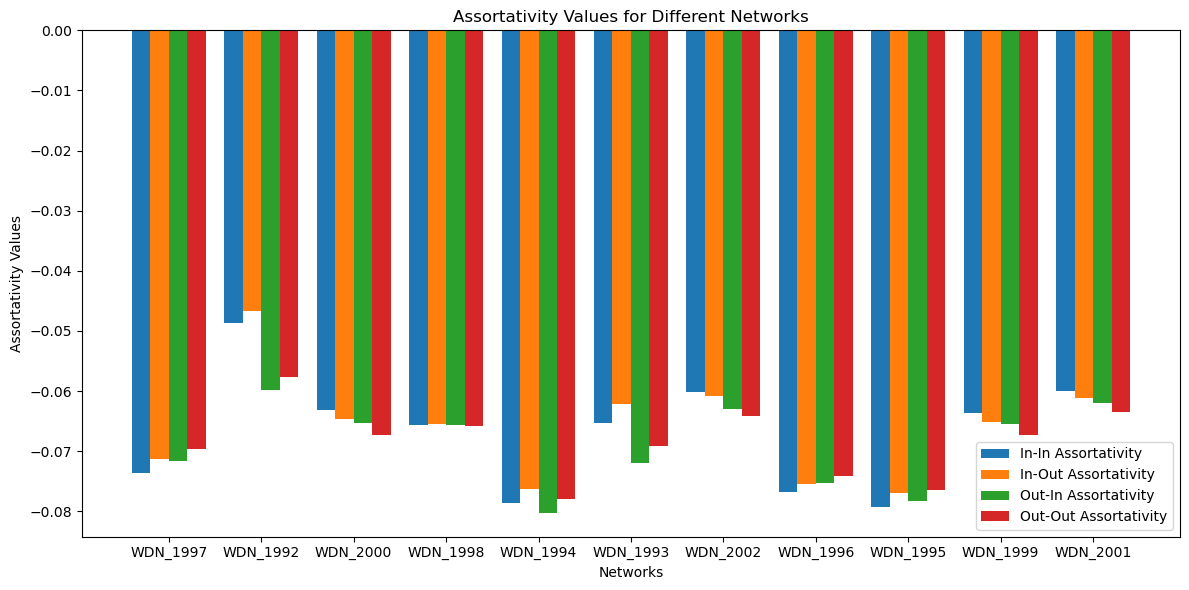

In [204]:
# Extracting graph names and assortativity values
graph_names = list(assortativities.keys())
keys = list(assortativities[graph_names[0]].keys())  # Extracting keys for assortativity values
values = {graph_name: [assortativities[graph_name][key] for key in keys] for graph_name in graph_names}

# Creating side-by-side bar plots for each network
bar_width = 0.2  # Width of each bar
index = np.arange(len(graph_names))  # Index for the networks

plt.figure(figsize=(12, 6))

for i, key in enumerate(keys):
    plt.bar(index + (i * bar_width), [values[graph_name][i] for graph_name in graph_names], bar_width, label=key)

plt.xlabel('Networks')
plt.ylabel('Assortativity Values')
plt.title('Assortativity Values for Different Networks')
plt.xticks(index + (bar_width * (len(keys) - 1) / 2), graph_names)
plt.legend()
plt.tight_layout()

plt.show()

## 2. Fit the Undirected Enhanced CM and Directed Enhanced CM using the CReMa method.
Hint: You can use the nemtropy package on networkx to deploy these methods. You can find some examples
at https://github.com/nicoloval/NEMtropy/blob/master/examples/Directed%20Graphs.
ipynb. For additional questions, do not hesitate to ask at the QA.

## 3. Sample 30 networks from the obtained ERGM distributions and measure the strength assortativity on all of them. Calculate average and standard deviation of each assortativity typology.

## 4. Plot strength assortativity as a function of time (the WTW network year), comparing the observed real value with the average and error bars obtained from the samples samples.
Hint: plot error bars as confidence intervals. Plot all pairs of assortativity for the undirected and directed
case(in-in, in-out, out-out)

## 5. Write a short paragraph to comment on the interpretation of strength assortativity for this dataset, and about the conclusions you can draw via the inference you made using the ERGM models.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results.pdf`

# III Robustness

## 1. Generate synthetic networks (you can use whatever module you prefer):
1. Random networks (ErdosRényi) (with $n = 1000$ and $\langle k \rangle = \{1,4\}$)
2. Scale-free networks (Barabási-Albert) (with $n = 1000$ and $m = \{2,4\}$)

In [210]:
N = 1000
K_VALUES = range(1, 5, 1)
M_VALUES = range(2, 5, 1)
CONSIDERED_GRAPHS = ['graph_eu_airlines', 'graph_power']

In [211]:
er_graphs = {}
ba_graphs = {}

In [220]:
def generate_ER_graphs(nodes, k_values, number):
    graphs = {}
    
    # Generate n graphs for each k value
    for avg_degree in k_values:
        graphs[avg_degree] = {}
    
        for index in range(1, number+1, 1):
            
            probability = avg_degree / (nodes - 1)
            
            graph = nx.erdos_renyi_graph(n=nodes, p=probability)
            
            graphs[avg_degree][index] = graph
            
    return graphs

In [231]:
er_graphs = generate_ER_graphs(nodes=N, k_values=K_VALUES, number=2)
er_graphs

{1: {1: <networkx.classes.graph.Graph at 0x19f052a90>,
  2: <networkx.classes.graph.Graph at 0x1a1755410>},
 2: {1: <networkx.classes.graph.Graph at 0x1a21f2010>,
  2: <networkx.classes.graph.Graph at 0x1a0bc44d0>},
 3: {1: <networkx.classes.graph.Graph at 0x1a177db50>,
  2: <networkx.classes.graph.Graph at 0x1a03b2950>},
 4: {1: <networkx.classes.graph.Graph at 0x1a0462550>,
  2: <networkx.classes.graph.Graph at 0x1a0508a90>}}

In [223]:
def generate_BA_graphs(nodes, m_values, number):
    graphs = {}

    # Generate n graphs for each m value
    for m in m_values:
        graphs[m] = {}

        for index in range(1, number+1, 1):

            graph = nx.barabasi_albert_graph(n=nodes, m=m)

            graphs[m][index] = graph

    return graphs

In [266]:
ba_graphs = generate_BA_graphs(nodes=N, m_values=M_VALUES, number=2)
ba_graphs

{2: {1: <networkx.classes.graph.Graph at 0x1ddb10e90>,
  2: <networkx.classes.graph.Graph at 0x1dde6ad50>},
 3: {1: <networkx.classes.graph.Graph at 0x1dde6b090>,
  2: <networkx.classes.graph.Graph at 0x1ddecde90>},
 4: {1: <networkx.classes.graph.Graph at 0x1ddfaa6d0>,
  2: <networkx.classes.graph.Graph at 0x1de0285d0>}}

## 2. Plot the degree distributions of the synthetic networks and of the networks provided in the datasets.

In [313]:
def plot_degree_distribution(ax, graph, color, param, graph_index, er):
    degrees = [degree for node, degree in graph.degree()]
    degree_freq = nx.degree_histogram(graph)
    ax.bar(range(len(degree_freq)), degree_freq, width=0.8, color=color)
    ax.set_xlabel('Degree')
    ax.set_ylabel('Frequency')
    if er:
        ax.set_title(fr"Degree Distribution of graph iteration {graph_index} with $\langle k \rangle = {param}$")
    else:
        ax.set_title(fr"Degree Distribution of graph iteration {graph_index} with $m = {param}$")
    

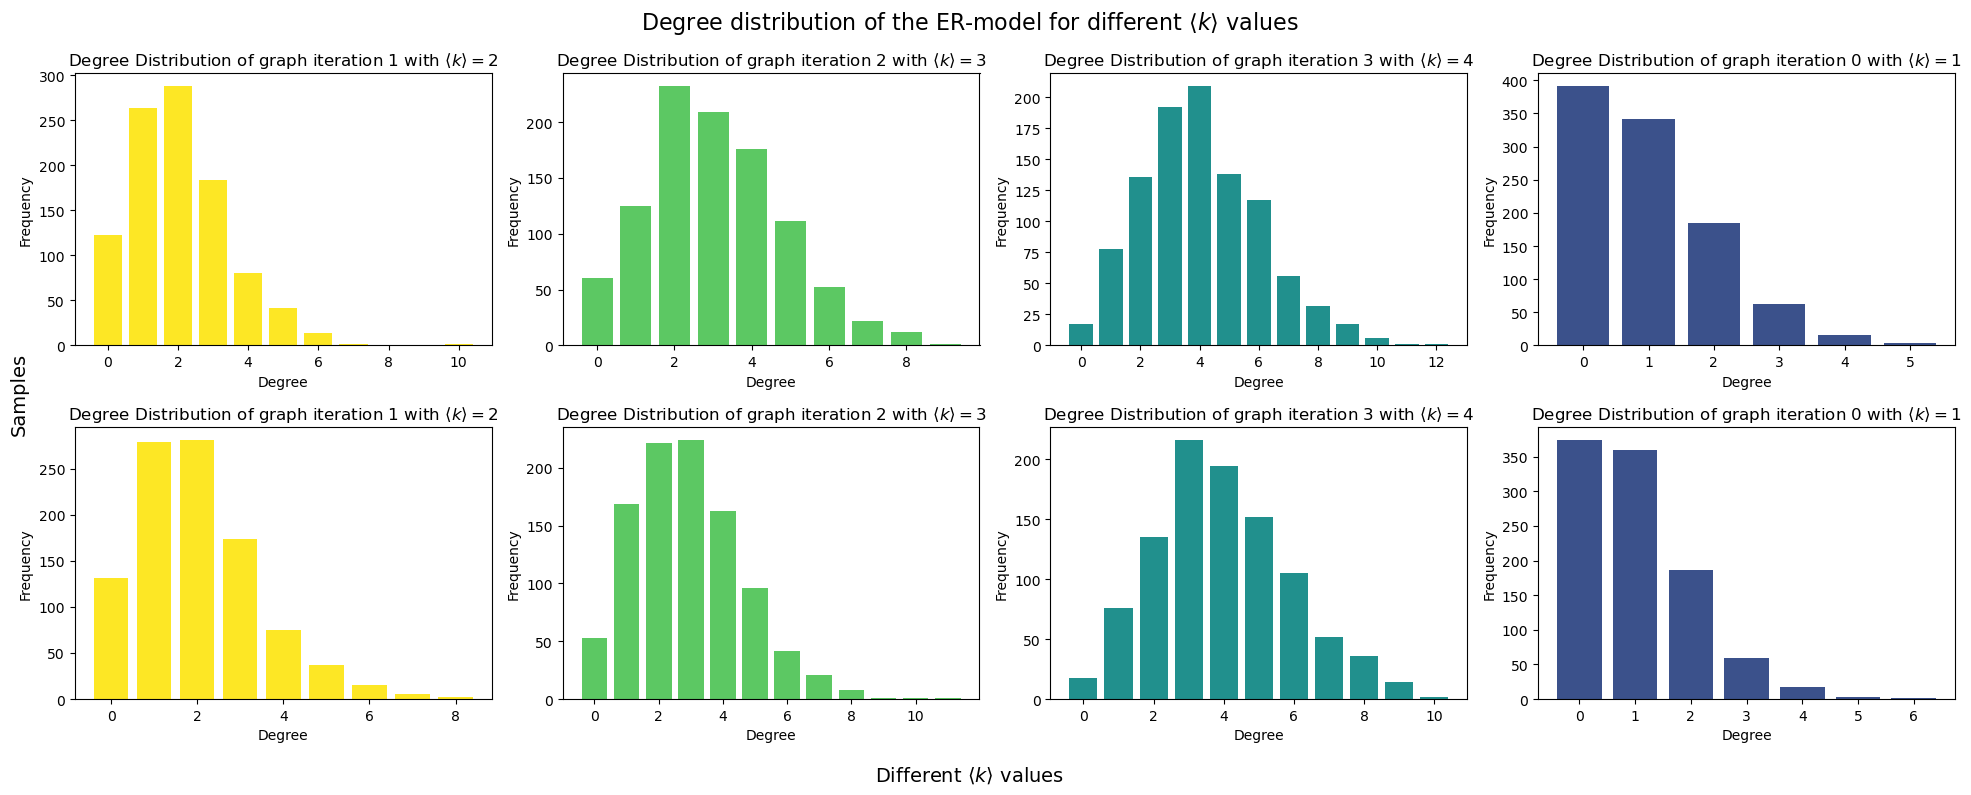

In [314]:
# ER-graphs
# Define colors for different average degrees using a colormap
num_avg_degrees = len(er_graphs)
colors = plt.cm.viridis_r([i / num_avg_degrees for i in range(num_avg_degrees)])

# Create a subplot grid
num_instances = len(next(iter(er_graphs.values())))  # Assuming all instances have the same count
fig, axs = plt.subplots(num_instances, num_avg_degrees, figsize=(20, 8))

# Iterate through avg_degree_index and graph_index
for avg_degree_index, (avg_degree, avg_degree_plots) in enumerate(er_graphs.items()):
    color = colors[avg_degree_index - 1]  # Get color for the degree
    for graph_index, graph in avg_degree_plots.items():
        # Get the appropriate axis for the subplot
        if num_instances == 1:
            ax = axs[avg_degree_index - 1]
        else:
            ax = axs[graph_index - 1, avg_degree_index - 1]

        # Plot on the corresponding axis with the assigned color
        plot_degree_distribution(ax=ax, graph=graph, color=color, param=avg_degree, graph_index=avg_degree_index, er=True)


fig.suptitle(fr"Degree distribution of the ER-model for different $\langle k \rangle$ values", fontsize=16)
fig.supxlabel(fr"Different $\langle k \rangle$ values", fontsize=14)
fig.supylabel("Samples", fontsize=14)


# Adjust layout and display the plot
plt.tight_layout()
plt.show()

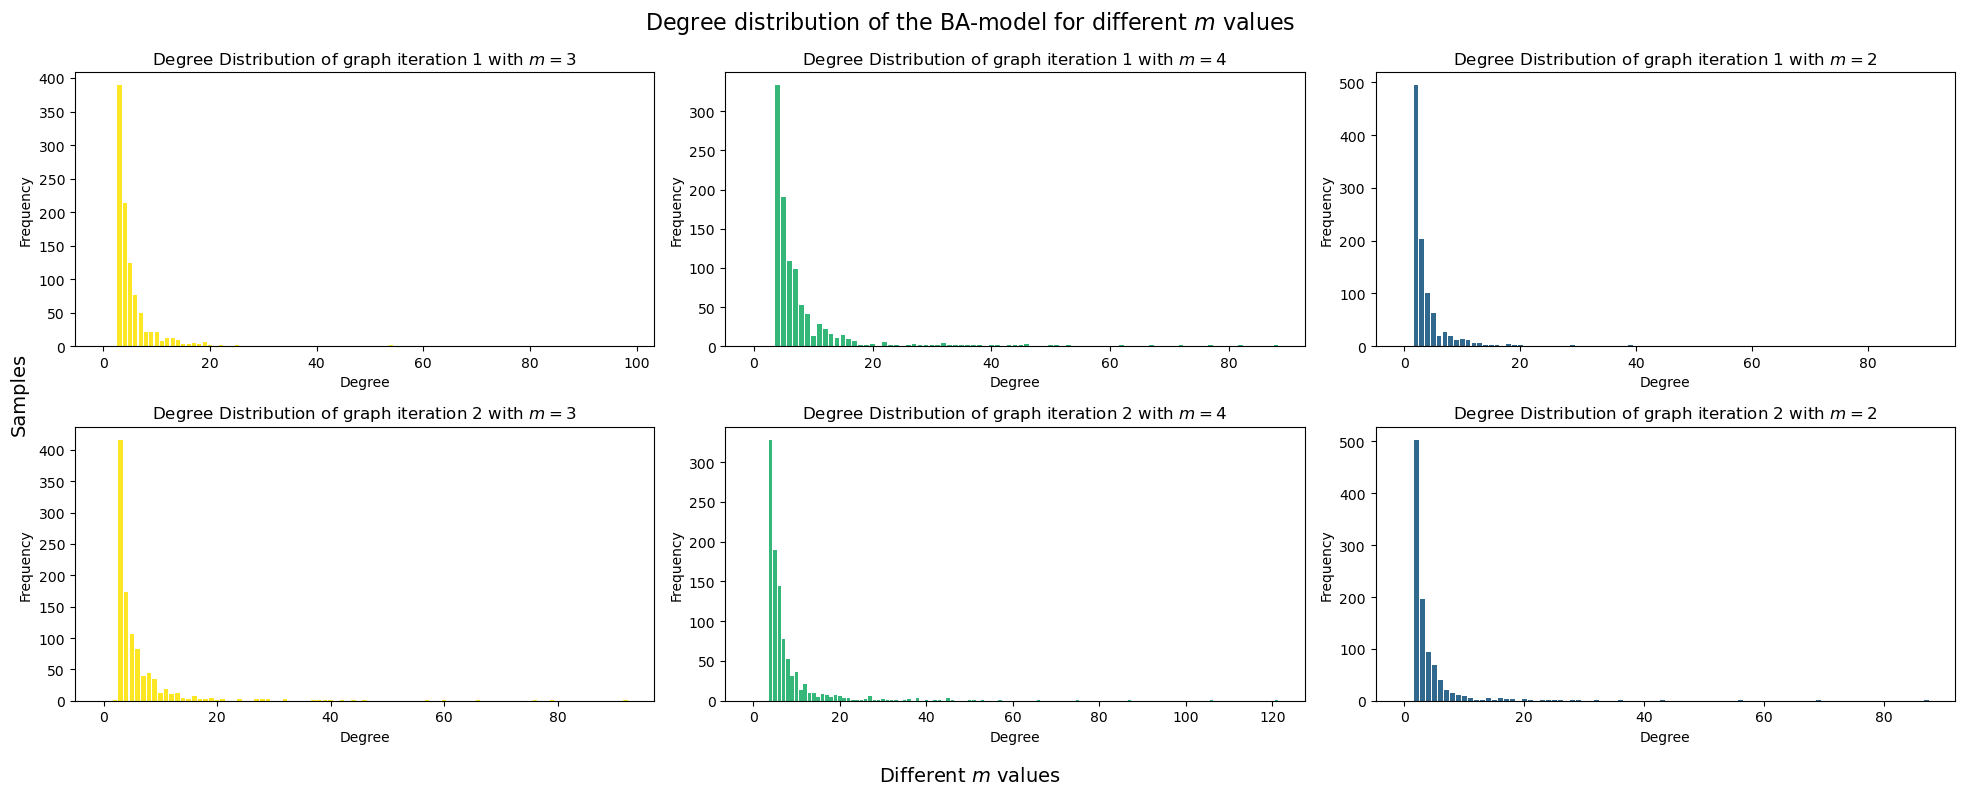

In [315]:
# BA-graphs
# Define colors for different average degrees using a colormap
num_ba_values = len(ba_graphs)
colors = plt.cm.viridis_r([i / num_ba_values for i in range(num_ba_values)])
# Create a subplot grid
num_instances = len(next(iter(ba_graphs.values())))  # Assuming all instances have the same count
fig, axs = plt.subplots(num_instances, num_ba_values, figsize=(20, 8))

# Iterate through avg_degree_index and graph_index
for m_index, (m, m_plots) in enumerate(ba_graphs.items()): # Do not forget that m is not an index -> use enumerate and m_index
    color = colors[m_index - 1]  # Get color for the degree
    for graph_index, graph in m_plots.items():
        # Get the appropriate axis for the subplot
        if num_instances == 1:
            ax = axs[m_index - 1]
        else:
            ax = axs[graph_index - 1, m_index - 1]

        # Plot on the corresponding axis with the assigned color
        plot_degree_distribution(ax=ax, graph=graph, color=color, param=m, graph_index=graph_index, er=False)

fig.suptitle(fr"Degree distribution of the BA-model for different $m$ values", fontsize=16)
fig.supxlabel(fr"Different $m$ values", fontsize=14)
fig.supylabel("Samples", fontsize=14)


# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## 3. Plot the size of the largest connected component as a function of removed edges and nodes in two scenarios for the synthetic graphs and the real networks in the datasets:
(a) Random attacks (failures)
(b) Targeted attacks (degree centrality and betweenness centrality)

## 4. Comment the plots, using what we discussed in class.